# Plots Visualised

Notebook workspace for inspecting and saving project figures to `results/figures`.

In [ ]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import seaborn as sns

project_root = Path.cwd()
if project_root.name == "src":
    project_root = project_root.parent
src_dir = project_root / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from utils import FEATURES_CSV_PATH, FIGURES_DIR, IMGS_DIR, METADATA_CSV_PATH

FIGURES_PATH = Path(FIGURES_DIR)
FIGURES_PATH.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")

# Set save=True to write the figure to results/figures.

## Dataset Exploration and Metadata

Quick checks of metadata composition, diagnosis balance, and patient/image distributions.

In [9]:
metadata_df = pd.read_csv(METADATA_CSV_PATH)
metadata_df.head()

,patient_id,lesion_id,smoke,drink,background_father,background_mother,age,pesticide,gender,skin_cancer_history,...,diameter_2,diagnostic,itch,grew,hurt,changed,bleed,elevation,img_id,biopsed
0,PAT_1516,1765,NaN,NaN,NaN,NaN,8,NaN,NaN,NaN,...,NaN,NEV,False,False,False,False,False,False,PAT_1516_1765_530.png,False
1,PAT_46,881,False,False,POMERANIA,POMERANIA,55,False,FEMALE,True,...,5.0,BCC,True,True,False,True,True,True,PAT_46_881_939.png,True
2,PAT_1545,1867,NaN,NaN,NaN,NaN,77,NaN,NaN,NaN,...,NaN,ACK,True,False,False,False,False,False,PAT_1545_1867_547.png,False
3,PAT_1989,4061,NaN,NaN,NaN,NaN,75,NaN,NaN,NaN,...,NaN,ACK,True,False,False,False,False,False,PAT_1989_4061_934.png,False
4,PAT_684,1302,False,True,POMERANIA,POMERANIA,79,False,MALE,True,...,5.0,BCC,True,True,False,False,True,True,PAT_684_1302_588.png,True


In [10]:
def _finish_plot(filename, save=False, show=True):
    if save:
        plt.savefig(os.path.join(FIGURES_DIR, filename), dpi=300, bbox_inches="tight")
    if show:
        plt.show()
    plt.close()


def plot_diagnosis_distribution(df, save=False, show=True):
    colors = [
        "#2ecc71" if diag in ["ACK", "NEV", "SEK"] else "#e74c3c"
        for diag in df["diagnostic"].value_counts().index
    ]
    custom_lines = [
        Line2D([0], [0], color="#2ecc71", lw=4),
        Line2D([0], [0], color="#e74c3c", lw=4),
    ]

    ax = df["diagnostic"].value_counts().plot(kind="bar", color=colors)
    plt.xlabel("Diagnosis")
    plt.ylabel("Count")
    ax.legend(custom_lines, ["Disease", "Cancer"])

    for i, v in enumerate(df["diagnostic"].value_counts().values):
        ax.text(i, v + 5, str(v), ha="center", fontweight="bold")

    _finish_plot("diag-dist.png", save=save, show=show)


def plot_diagnosis_percentage_distribution(df, save=False, show=True):
    counts = df["diagnostic"].value_counts()

    counts.plot.pie(autopct="%1.1f%%")
    plt.ylabel("")
    plt.tight_layout()
    _finish_plot("diag-percentage-dist.png", save=save, show=show)


def plot_images_per_patient_distribution(df, save=False, show=True):
    patient_counts = df["patient_id"].value_counts()
    distribution = patient_counts.value_counts().sort_index()

    distribution.plot(kind="bar")
    plt.xlabel("Number of images per patient")
    plt.ylabel("Number of patients")

    for i, v in enumerate(distribution.values):
        plt.text(i, v + 2, str(v), ha="center")

    _finish_plot("images_per_patient_distribution.png", save=save, show=show)


def plot_patiens_per_diagnosis(df, save=False, show=True):
    patient_diagnosis = df.groupby("patient_id")["diagnostic"].first()
    diagnosis_counts = patient_diagnosis.value_counts()

    ax = diagnosis_counts.plot(kind="bar")
    plt.xlabel("Diagnosis")
    plt.ylabel("Number of patients")
    plt.xticks(rotation=45)

    for i, v in enumerate(diagnosis_counts.values):
        ax.text(i, v + 5, str(v), ha="center", fontweight="bold")

    plt.tight_layout()
    _finish_plot("patiens_per_diagnosis.png", save=save, show=show)

## Feature Space and Statistical Analysis

Section for feature distributions, correlations, and summary statistics.

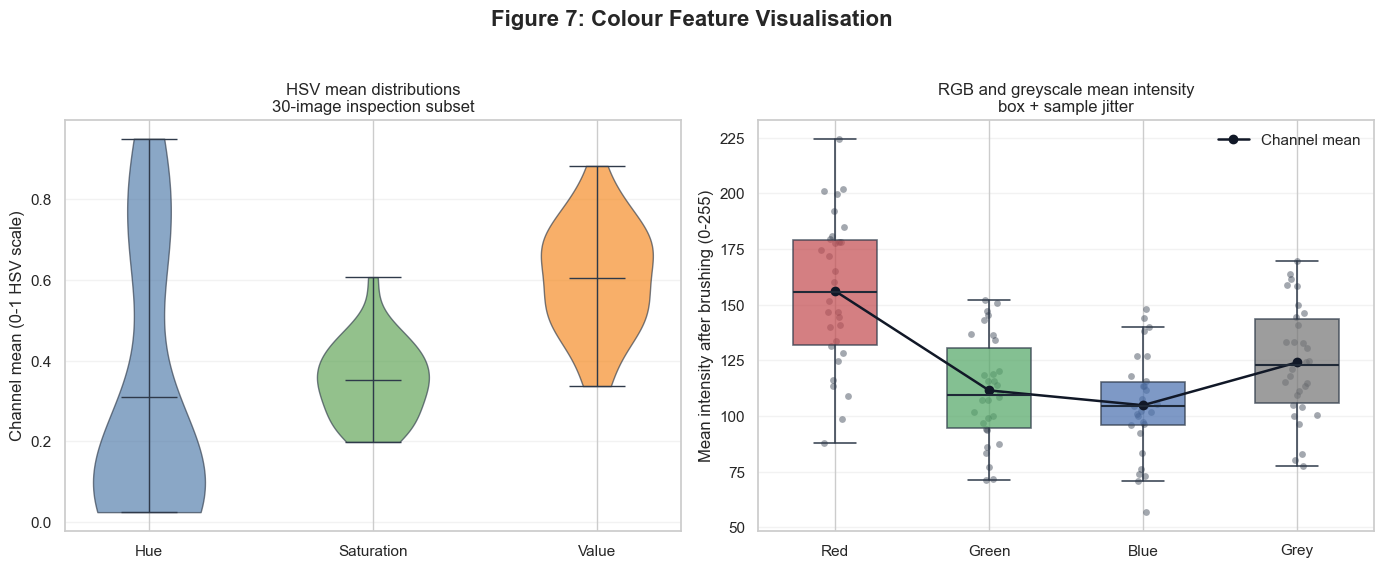

In [4]:
from utils import EXTENDED_FEATURES_CSV_PATH, TESTING_BASELINE_FEATURES_CSV_PATH


FIGURE_7_HSV_COLUMNS = ["hue_mean", "saturation_mean", "value_mean"]
FIGURE_7_RGB_COLUMNS = ["red_mean", "green_mean", "blue_mean", "grey_mean"]


def plot_figure_7_colour_features():
    baseline_subset = pd.read_csv(TESTING_BASELINE_FEATURES_CSV_PATH)
    extended_features = pd.read_csv(EXTENDED_FEATURES_CSV_PATH)
    subset_ids = set(baseline_subset["img_id"].astype(str))
    extended_subset = extended_features[
        extended_features["img_id"].astype(str).isin(subset_ids)
    ].copy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    hsv_values = [baseline_subset[column].dropna().to_numpy() for column in FIGURE_7_HSV_COLUMNS]
    violin = axes[0].violinplot(hsv_values, showmeans=True, showextrema=True)
    for body, color in zip(violin["bodies"], ["#4c78a8", "#59a14f", "#f58518"]):
        body.set_facecolor(color)
        body.set_edgecolor("#2f3a4a")
        body.set_alpha(0.65)
    for key in ("cmeans", "cmins", "cmaxes", "cbars"):
        violin[key].set_color("#2f3a4a")
        violin[key].set_linewidth(1)
    axes[0].set_xticks([1, 2, 3])
    axes[0].set_xticklabels(["Hue", "Saturation", "Value"])
    axes[0].set_ylabel("Channel mean (0-1 HSV scale)")
    axes[0].set_title("HSV mean distributions\n30-image inspection subset")
    axes[0].grid(axis="y", alpha=0.25)

    rgb_values = [extended_subset[column].dropna().to_numpy() for column in FIGURE_7_RGB_COLUMNS]
    boxplot = axes[1].boxplot(
        rgb_values,
        patch_artist=True,
        widths=0.55,
        showfliers=False,
        medianprops={"color": "#1f2937", "linewidth": 1.5},
        boxprops={"edgecolor": "#2f3a4a", "linewidth": 1.2},
        whiskerprops={"color": "#2f3a4a", "linewidth": 1.1},
        capprops={"color": "#2f3a4a", "linewidth": 1.1},
    )
    for patch, color in zip(boxplot["boxes"], ["#c44e52", "#55a868", "#4c72b0", "#777777"]):
        patch.set_facecolor(color)
        patch.set_alpha(0.72)

    rng = np.random.default_rng(11037)
    for idx, values in enumerate(rgb_values, start=1):
        jitter = rng.normal(0, 0.045, size=len(values))
        axes[1].scatter(
            np.full(len(values), idx) + jitter,
            values,
            s=24,
            color="#253041",
            alpha=0.42,
            linewidth=0,
        )

    channel_means = [values.mean() for values in rgb_values]
    axes[1].plot(
        range(1, len(channel_means) + 1),
        channel_means,
        color="#111827",
        marker="o",
        linewidth=1.8,
        label="Channel mean",
    )
    axes[1].set_xticks(range(1, len(FIGURE_7_RGB_COLUMNS) + 1))
    axes[1].set_xticklabels(["Red", "Green", "Blue", "Grey"])
    axes[1].set_ylabel("Mean intensity after brushing (0-255)")
    axes[1].set_title("RGB and greyscale mean intensity\nbox + sample jitter")
    axes[1].grid(axis="y", alpha=0.25)
    axes[1].legend(frameon=False)

    fig.suptitle("Figure 7: Colour Feature Visualisation", fontsize=16, fontweight="bold", y=1.03)
    fig.tight_layout()
    plt.show()
    return fig, axes


figure_7 = plot_figure_7_colour_features()

## Shortcut Processing

Section for shortcut-processing checks, masks, and cleaned-image comparisons.

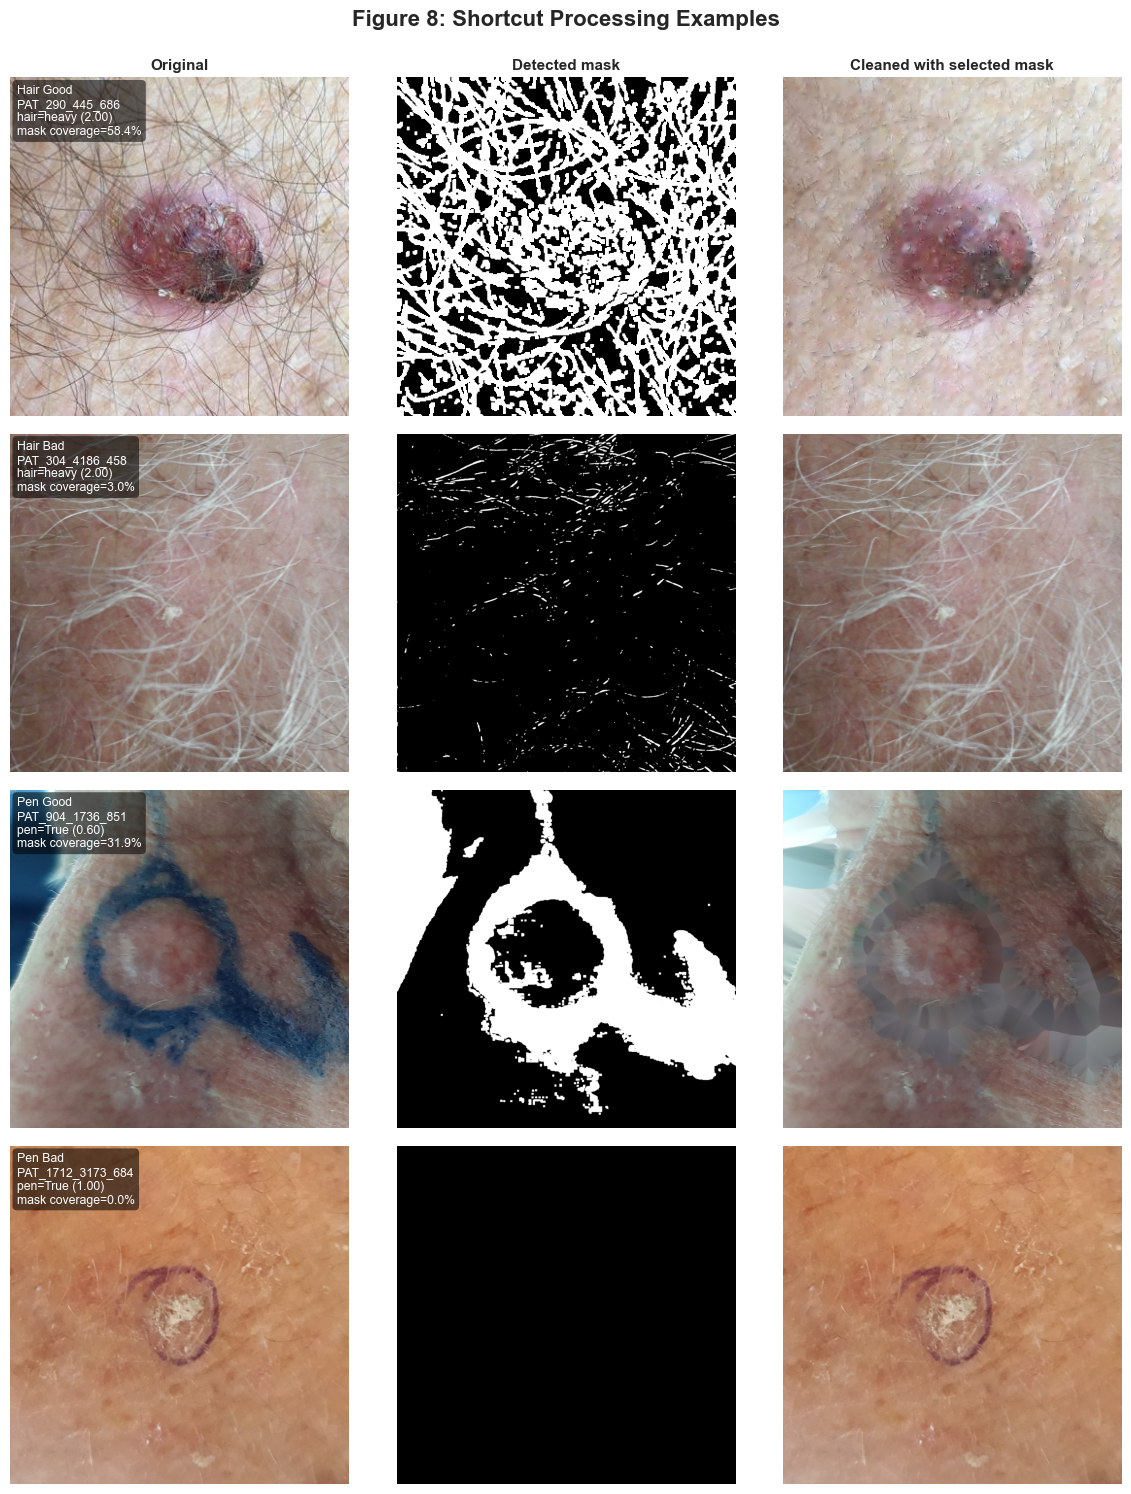

In [5]:
import cv2

from main_extraction import load_image_and_mask
from shortcuts import apply_shortcuts, load_shortcut_annotations


SHORTCUT_EXAMPLES = [
    {"kind": "Hair", "quality": "Good", "img_id": "PAT_290_445_686", "mask": "hair_mask"},
    {"kind": "Hair", "quality": "Bad", "img_id": "PAT_304_4186_458", "mask": "hair_mask"},
    {"kind": "Pen", "quality": "Good", "img_id": "PAT_904_1736_851", "mask": "pen_mask"},
    {"kind": "Pen", "quality": "Bad", "img_id": "PAT_1712_3173_684", "mask": "pen_mask"},
]


def _format_score(score):
    return "NA" if score is None else f"{score:.2f}"


def _mask_coverage(mask):
    return np.count_nonzero(mask) / mask.size


def _clean_with_selected_mask(image_rgb, selected_mask):
    image_rgb = np.ascontiguousarray(image_rgb[:, :, :3])
    image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
    cleaned_bgr = cv2.inpaint(image_bgr, selected_mask, 3, cv2.INPAINT_TELEA)
    return cv2.cvtColor(cleaned_bgr, cv2.COLOR_BGR2RGB)


def plot_figure_8_shortcut_examples():
    shortcut_annotations = load_shortcut_annotations()
    fig, axes = plt.subplots(len(SHORTCUT_EXAMPLES), 3, figsize=(12, 15))
    column_titles = ["Original", "Detected mask", "Cleaned with selected mask"]
    for axis, title in zip(axes[0], column_titles):
        axis.set_title(title, fontsize=11, fontweight="bold")

    for row_idx, example in enumerate(SHORTCUT_EXAMPLES):
        image, _ = load_image_and_mask(example["img_id"])
        result = apply_shortcuts(
            image,
            img_id=example["img_id"],
            annotations=shortcut_annotations,
        )
        selected_mask = getattr(result, example["mask"])
        cleaned_image = _clean_with_selected_mask(image, selected_mask)
        decision = result.decision

        panels = [
            (image, None),
            (selected_mask, "gray"),
            (cleaned_image, None),
        ]
        for axis, (panel, cmap) in zip(axes[row_idx], panels):
            axis.imshow(panel, cmap=cmap, vmin=0 if cmap else None, vmax=255 if cmap else None)
            axis.axis("off")

        if example["kind"] == "Hair":
            decision_text = f"hair={decision.hair_level} ({_format_score(decision.hair_score)})"
        else:
            decision_text = f"pen={decision.pen_present} ({_format_score(decision.pen_score)})"

        axes[row_idx, 0].text(
            0.02,
            0.98,
            f"{example['kind']} {example['quality']}\n{example['img_id']}\n{decision_text}\nmask coverage={_mask_coverage(selected_mask):.1%}",
            transform=axes[row_idx, 0].transAxes,
            ha="left",
            va="top",
            fontsize=8.8,
            color="white",
            bbox={"boxstyle": "round,pad=0.35", "facecolor": "black", "edgecolor": "none", "alpha": 0.55},
        )

    fig.suptitle("Figure 8: Shortcut Processing Examples", fontsize=16, fontweight="bold", y=0.995)
    fig.tight_layout()
    plt.show()
    return fig, axes


figure_8 = plot_figure_8_shortcut_examples()

## Model Evaluation and Performance

Section for confusion matrices, metric summaries, and performance diagnostics.